# cpssbench, the MNIST way

Load a cyber-physical intrusion dataset, draw a grid of windows with PyTorch, and train a small convolutional network. Each sample is a 1-channel window, `(channels, time, signals)`, with label `0` benign and `1` attack.

The ambient/`train` split is benign. The `test` split is the attack traces. A classifier therefore needs samples from both, unlike MNIST where every class is already in the training set.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import ConcatDataset, DataLoader, Subset

import cpssbench as bench

ROOT = Path("./data")
DATASETS = ["syncan"]  # add "road" to include the ROAD traces
GRID = 8
PER_CLASS = 512
BATCH_SIZE = 64
EPOCHS = 3
SEED = 0

torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("cpssbench", getattr(bench, "__version__", "local"))

device: cpu
cpssbench 0.1.0


## Catalog

`list_datasets()` is the equivalent of knowing which torchvision datasets exist. Only `ready` names can be downloaded and trained below.

In [2]:
catalog = bench.list_datasets()
for row in catalog:
    print(f"{row['name']:16} {row['status']:8} shape={row['input_shape']}")

syncan           ready    shape=(1, 50, 20)
road             ready    shape=(1, 50, 20)
misbehaviorx     manual   shape=(1, 10, 12)
x-canids         planned  shape=None


## Load

The first run downloads and windows the traces. Later runs reuse files under `ROOT`.

In [3]:
loaded = {}
for name in DATASETS:
    benign = bench.load(name, root=ROOT, split="train", download=True)
    attack = bench.load(name, root=ROOT, split="test", download=True)
    window, label = benign[0]
    print(f"{name}: window {tuple(window.shape)} label {label}  benign {len(benign)}  attack {len(attack)}")
    loaded[name] = {"benign": benign, "attack": attack}

syncan: window (1, 50, 20) label 0  benign 2966580  attack 1113614


## Sample grid

Windows are stacked into an image with PyTorch, the same idea as `torchvision.utils.make_grid`. Gray cells are benign. Red-tinted cells are attack.

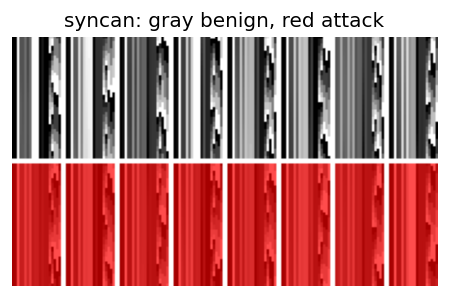

In [4]:
def take(dataset, n, seed):
    n = min(n, len(dataset))
    generator = torch.Generator().manual_seed(seed)
    index = torch.randperm(len(dataset), generator=generator)[:n]
    return Subset(dataset, index.tolist())


def tint(window, label):
    image = window.expand(3, -1, -1).clone()
    if int(label) == 1:
        image[0] = torch.clamp(image[0] * 0.35 + 0.65, 0, 1)
        image[1] *= 0.3
        image[2] *= 0.3
    return image


def make_grid(images, nrow=8, padding=2):
    """Stack (N, C, H, W) tensors into one (C, H', W') grid."""
    count, channels, height, width = images.shape
    cols = min(nrow, count)
    rows = (count + cols - 1) // cols
    canvas = images.new_ones(
        channels,
        rows * height + (rows - 1) * padding,
        cols * width + (cols - 1) * padding,
    )
    for i, image in enumerate(images):
        row, col = divmod(i, cols)
        y = row * (height + padding)
        x = col * (width + padding)
        canvas[:, y : y + height, x : x + width] = image
    return canvas


def plot_grid(name, benign, attack, n=GRID):
    benign_part = take(benign, n, SEED)
    attack_part = take(attack, n, SEED + 1)
    windows, labels = [], []
    for dataset, label in ((benign_part, 0), (attack_part, 1)):
        for window, _ in dataset:
            windows.append(tint(window, label))
            labels.append(label)
    batch = torch.stack(windows)
    grid = make_grid(batch, nrow=n)
    fig, ax = plt.subplots(figsize=(n * 1.1, 2.6))
    ax.imshow(grid.permute(1, 2, 0).cpu())
    ax.set_title(f"{name}: gray benign, red attack")
    ax.set_axis_off()
    fig.tight_layout()
    plt.show()
    return labels


for name, splits in loaded.items():
    plot_grid(name, splits["benign"], splits["attack"])

## A small network

This is the MNIST CNN shape: two convolutions, pooling, then a linear head. `AdaptiveAvgPool2d` keeps the same model usable when window sizes differ across datasets.

In [5]:
class SmallNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
        )
        self.pool = nn.AdaptiveAvgPool2d((4, 4))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))


def balanced_split(benign, attack, n, seed):
    data = ConcatDataset([take(benign, n, seed), take(attack, n, seed + 1)])
    generator = torch.Generator().manual_seed(seed)
    order = torch.randperm(len(data), generator=generator).tolist()
    cut = int(0.8 * len(order))
    return Subset(data, order[:cut]), Subset(data, order[cut:])


def run_epoch(model, loader, optimizer=None):
    train = optimizer is not None
    model.train(train)
    total_loss, correct, count = 0.0, 0, 0
    for windows, labels in loader:
        windows = windows.to(device)
        labels = labels.to(device).long()
        if train:
            optimizer.zero_grad()
        logits = model(windows)
        loss = nn.functional.cross_entropy(logits, labels)
        if train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        count += labels.size(0)
    return total_loss / max(count, 1), correct / max(count, 1)


results = {}
for name, splits in loaded.items():
    train_set, test_set = balanced_split(splits["benign"], splits["attack"], PER_CLASS, SEED)
    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=BATCH_SIZE)
    model = SmallNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    history = []
    print(f"\n{name}: train {len(train_set)}  test {len(test_set)}")
    _, train_acc = run_epoch(model, train_loader)
    _, test_acc = run_epoch(model, test_loader)
    history.append((0, None, train_acc, None, test_acc))
    print(f"  epoch 0: train acc {train_acc:.3f}  test acc {test_acc:.3f}  (untrained)")
    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = run_epoch(model, train_loader, optimizer)
        test_loss, test_acc = run_epoch(model, test_loader)
        history.append((epoch, train_loss, train_acc, test_loss, test_acc))
        print(f"  epoch {epoch}: train acc {train_acc:.3f}  test acc {test_acc:.3f}")
    results[name] = {"model": model, "test_set": test_set, "history": history}


syncan: train 819  test 205
  epoch 1: train acc 0.902  test acc 0.898
  epoch 2: train acc 0.904  test acc 0.898
  epoch 3: train acc 0.904  test acc 0.898


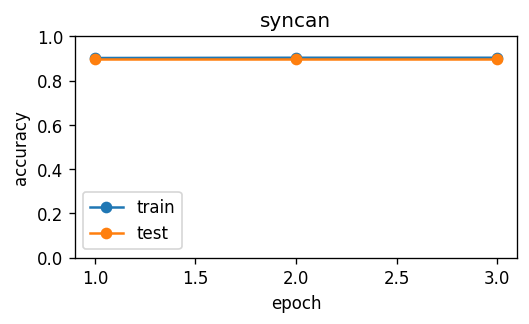

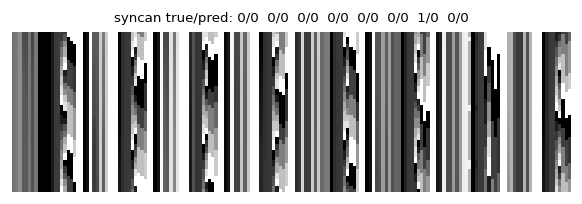

In [6]:
def plot_predictions(name, model, dataset, n=GRID):
    model.eval()
    windows, true_labels, pred_labels = [], [], []
    with torch.no_grad():
        for i in range(min(n, len(dataset))):
            window, label = dataset[i]
            pred = model(window.unsqueeze(0).to(device)).argmax(1).item()
            windows.append(tint(window, pred))
            true_labels.append(int(label))
            pred_labels.append(pred)
    grid = make_grid(torch.stack(windows), nrow=n)
    fig, ax = plt.subplots(figsize=(n * 1.1, 1.8))
    ax.imshow(grid.permute(1, 2, 0).cpu())
    title = "  ".join(f"{t}/{p}" for t, p in zip(true_labels, pred_labels))
    ax.set_title(f"{name} true/pred: {title}", fontsize=8)
    ax.set_axis_off()
    fig.tight_layout()
    plt.show()


for name, item in results.items():
    epochs, train_loss, train_acc, test_loss, test_acc = zip(*item["history"])
    fig, ax = plt.subplots(figsize=(4.5, 2.8))
    ax.plot(epochs, train_acc, marker="o", label="train")
    ax.plot(epochs, test_acc, marker="o", label="test")
    ax.set_xlim(left=0)
    ax.set_xticks(list(epochs))
    ax.set_ylim(0, 1)
    ax.set_xlabel("epoch")
    ax.set_ylabel("accuracy")
    ax.set_title(name)
    ax.legend()
    fig.tight_layout()
    plt.show()
    plot_predictions(name, item["model"], item["test_set"])